<a href="https://colab.research.google.com/github/ramrpm/skills-copilot-codespaces-vscode/blob/main/Ch03-linreg-lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Linear Regression

<a target="_blank" href="https://colab.research.google.com/github/intro-stat-learning/ISLP_labs/blob/v2.2/Ch03-linreg-lab.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/intro-stat-learning/ISLP_labs/v2.2?labpath=Ch03-linreg-lab.ipynb)


## Importing packages
We import our standard libraries at this top
level.

In [8]:
pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━

In [10]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots


### New imports
A lo largo de este laboratorio presentaremos nuevas funciones y bibliotecas. Sin embargo, las importaremos aquí para destacar que estos son los nuevos objetos de código en este laboratorio. Mantener las importaciones cerca del inicio de un notebook hace que el código sea más legible, ya que al escanear las primeras líneas podemos saber qué bibliotecas se están utilizando.

In [11]:
import statsmodels.api as sm


Proporcionaremos detalles relevantes sobre las funciones más adelante, a medida que se necesiten.

Además de importar módulos completos, también es posible importar solo algunos elementos específicos de un módulo determinado. Esto ayuda a mantener limpio el espacio de nombres. Utilizaremos algunos objetos específicos del paquete `statsmodels`, los cuales importamos aquí.  

In [9]:
from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm


Como una de las instrucciones de importación anteriores es bastante larga, insertamos un salto de línea \ para facilitar la lectura.

También utilizaremos algunas funciones escritas específicamente para los laboratorios de este libro, incluidas en el paquete ISLP.

In [12]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)


### Inspección de objetos y espacios de nombres
La función `dir()` proporciona una lista de objetos en un espacio de nombres.



In [13]:
dir()


['In',
 'MS',
 'Out',
 'VIF',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_exit_code',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'anova_lm',
 'exit',
 'get_ipython',
 'load_data',
 'np',
 'pd',
 'poly',
 'quit',
 'sm',
 'subplots',
 'summarize']

Esto muestra todo lo que Python puede encontrar en el nivel superior. Hay ciertos objetos como __builtins__ que contienen referencias a funciones incorporadas como print().

Cada objeto en Python tiene su propio espacio de nombres, el cual también se puede acceder con dir(). Esto incluye tanto los atributos del objeto como los métodos asociados a él. Por ejemplo, podemos ver 'sum' en el listado de un arreglo (array).

In [14]:
A = np.array([3,5,11])
dir(A)


['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '_

Esto indica que el objeto A.sum existe. En este caso, se trata de un método que puede utilizarse para calcular la suma del arreglo A, como puede comprobarse escribiendo A.sum?.

In [9]:
A.sum()


np.int64(19)

## Simple Linear Regression
En esta sección construiremos matrices de diseño (también llamadas matrices del modelo) utilizando la transformación `ModelSpec()` del módulo ISLP.models.

Usaremos el conjunto de datos de viviendas de Boston, el cual está incluido en el paquete ISLP. Este conjunto de datos registra el valor mediano de las viviendas `(medv)`
 para 506 vecindarios alrededor de Boston. Construiremos un modelo de regresión para predecir medv utilizando 13 variables predictoras, como:`rmvar`: número promedio de habitaciones por vivienda, age: proporción de unidades ocupadas por sus dueños construidas antes de 1940, `lstat`: porcentaje de hogares con bajo nivel socioeconómico.

Utilizaremos statsmodels para esta tarea, un paquete de Python que implementa varios métodos de regresión comúnmente utilizados.

Hemos incluido una función simple de carga de datos, `load_data()`, en el paquete ISLP.

In [15]:
Boston = load_data("Boston")
Boston.columns


Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

Escribir `Boston` para obtener más información sobre este conjunto de datos.

Comenzamos utilizando la función `sm.OLS()` para ajustar un modelo de regresión lineal simple. Nuestra variable dependiente será medv y lstat será el único predictor. Para este modelo, podemos crear la matriz del modelo manualmente.


In [16]:
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
                  'lstat': Boston['lstat']})
X[:4]


,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


Extraemos la variable de respuesta y ajustamos el modelo.

In [17]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()


Ténganse en cuenta que `sm.OLS()` no ajusta el modelo; solo lo especifica. El ajuste real se realiza con `model.fit()`.

Nuestra función `summarize()` del paquete ISLP genera una tabla sencilla con los estimadores de los parámetros, sus errores estándar, estadísticos t y valores p. Esta función recibe un único argumento, como el objeto results que se devuelve al aplicar el método fit, y retorna dicho resumen.

In [13]:
summarize(results)


,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


Antes de describir otros métodos para trabajar con modelos ajustados, presentaremos un enfoque más útil y general para construir una matriz del modelo X.
### Using Transformations: Fit and Transform
Nuestro modelo anterior tenía un único predictor, por lo que construir la matriz
𝑋 fue sencillo. Sin embargo, en la práctica solemos ajustar modelos con más de un predictor, generalmente seleccionados de un array o un data frame.

Además, puede que deseemos:

aplicar transformaciones a las variables antes de ajustar el modelo, especificar interacciones entre variables, o expandir ciertas variables en conjuntos de variables (por ejemplo, polinomios).

El paquete scikit-learn `(sklearn)` tiene un enfoque particular para este tipo de tareas: un transformador `(transform)`. Un transform es un objeto que se crea con algunos parámetros como argumentos, y tiene dos métodos principales: `fit()` y `transform()`.

En esta línea, ofrecemos un enfoque general para especificar modelos y construir matrices del modelo a través del transformador `ModelSpec()` de la biblioteca ISLP.
`ModelSpec()` `(abreviado como MS() en el preámbulo)` crea un objeto de transformación, al que luego se le aplican los métodos `fit()` y `transform()` para construir la matriz del modelo correspondiente.

Describiremos este proceso primero para nuestro modelo de regresión simple utilizando un solo predictor lstat del data frame Boston, pero lo utilizaremos repetidamente en tareas más complejas a lo largo de este y otros laboratorios del libro.

En nuestro caso, el transformador se crea con la expresión:

python
Copiar
Editar
design = MS(['lstat'])
El método `fit()` toma el array original y puede realizar algunos cálculos iniciales sobre él, como el centrado o escalado (media y desviación estándar), según esté especificado en el objeto transformador.

El método `transform()` aplica la transformación ajustada al array de datos y produce la matriz del modelo.


In [18]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


En este caso simple, el método `fit()` hace muy poco: simplemente verifica que la variable 'lstat' especificada en design exista en el data frame Boston. Luego, el método `transform()` construye la matriz del modelo con dos columnas: una intercepto y la variable lstat.

Estas dos operaciones —ajustar y transformar— pueden combinarse mediante el método `fit_transform()`.

In [19]:
design = MS(['lstat'])
X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


Observa que, al igual que en el fragmento de código anterior donde se realizaron los dos pasos por separado, el objeto design se modifica como resultado de la operación `fit()`.
El poder de esta pipeline se hará más evidente cuando ajustemos modelos más complejos que incluyan interacciones y transformaciones.

Volvamos a nuestro modelo de regresión ajustado. El objeto results tiene varios métodos útiles para realizar inferencia.
Ya presentamos la función `summarize()` para mostrar los elementos esenciales del ajuste.
Para obtener un resumen completo y detallado, podemos utilizar el método `summary()`.

In [20]:
results.summary()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Mon, 04 Aug 2025   Prob (F-statistic):           5.08e-88
Time:                        19:05:54   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.0

Los coeficientes ajustados también se pueden obtener mediante el atributo `params` del objeto `results`.

In [21]:
results.params


,0
intercept,34.553841
lstat,-0.950049


El método `get_prediction()` puede utilizarse para obtener predicciones, así como para generar intervalos de confianza e intervalos de predicción para el valor de medv dado ciertos valores de lstat.

Primero creamos un nuevo data frame, que en este caso contiene únicamente la variable lstat con los valores en los que deseamos realizar las predicciones. Luego, usamos el método `transform()` del objeto design para crear la matriz del modelo correspondiente.

In [22]:
new_df = pd.DataFrame({'lstat':[5, 10, 15]})
newX = design.transform(new_df)
newX


,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


A continuación, calculamos las predicciones en `newX` y las visualizamos extrayendo el atributo `predicted_mean`.

In [23]:
new_predictions = results.get_prediction(newX);
new_predictions.predicted_mean


array([29.80359411, 25.05334734, 20.30310057])

Podemos generar intervalos de confianza para los valores predichos.

In [24]:
new_predictions.conf_int(alpha=0.05)


array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

Los intervalos de predicción se calculan estableciendo `obs=True`:

In [25]:
new_predictions.conf_int(obs=True, alpha=0.05)


array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

Por ejemplo, el intervalo de confianza al 95 % asociado a un valor de lstat igual a 10 es `(24.47, 25.63)`, y el intervalo de predicción al 95 % es `(12.82, 37.28)`.
Como se espera, ambos intervalos están centrados en el mismo punto `(un valor predicho de 25.05 para medv cuando lstat es igual a 10)`, pero el intervalo de predicción es considerablemente más amplio.

A continuación, vamos a graficar medv contra lstat utilizando el método `DataFrame.plot.scatter() (plot.scatter())`, y deseamos agregar la línea de regresión al gráfico resultante.

### Definición de funciones
Aunque el paquete `ISLP` incluye una función que permite agregar una línea a un gráfico existente, aprovechamos esta oportunidad para definir nuestra primera función que cumpla con ese propósito.

In [26]:
def abline(ax, b, m):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim)


###Se ilustran algunos aspectos importantes en el ejemplo anterior:

Primero, observamos la sintaxis para definir una función en Python:

`def nombre_funcion(...)`:
La función tiene tres argumentos principales:

`ax`: un objeto axis correspondiente a un gráfico existente `(por ejemplo, creado con plot.scatter())`,

`b`: el intercepto de la línea que se desea trazar,

`m`: la pendiente de dicha línea.

Además, se pueden pasar otras opciones gráficas `(como color, estilo de línea, grosor, etc.)` directamente a `ax.plot()` utilizando argumentos adicionales mediante **kwargs. Esto permite que la función sea más flexible y personalizable.
Por ejemplo:

`def agregar_linea(ax, b, m, **kwargs)`:
    ...
    `ax.plot(x_vals, y_vals, **kwargs)`

In [28]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)


## En nuestra función, estos argumentos se pasan directamente a `ax.plot()` sin modificación.

Para quienes deseen profundizar más en la definición de funciones en Python, se recomienda consultar la sección correspondiente en la documentación oficial:
👉 https://docs.python.org/tutorial

Ahora, vamos a utilizar nuestra nueva función para agregar la línea de regresión al gráfico de `medv` contra `lstat`.
Por ejemplo:
`def abline(ax, b, m, *args, **kwargs):
    x_vals = np.array(ax.get_xlim())
    y_vals = b + m * x_vals
    ax.plot(x_vals, y_vals, *args, **kwargs)`

# Supongamos que ya tenemos un gráfico de dispersión
`ax = Boston.plot.scatter(x='lstat', y='medv')`

# Agregamos la línea de regresión
`abline(ax, b=results.params['const'], m=results.params['lstat'], color='red', linewidth=2)`

/tmp/ipython-input-1591428221.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0],
/tmp/ipython-input-1591428221.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1],


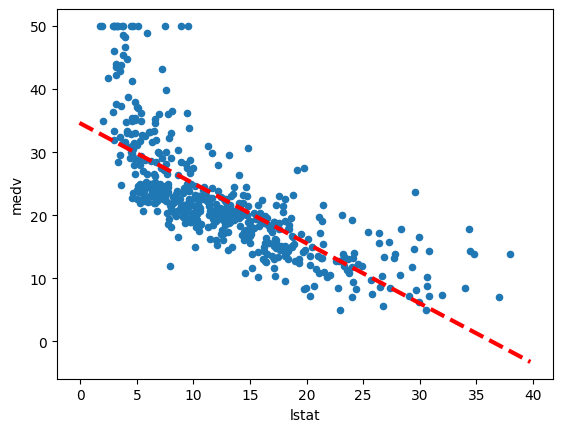

In [30]:
ax = Boston.plot.scatter('lstat', 'medv')
abline(ax,
       results.params[0],
       results.params[1],
       'r--',
       linewidth=3)


Así, la llamada final a `ax.plot()` es:

`ax.plot(xlim, ylim, 'r--', linewidth=3)`
Usamos el argumento 'r--' para generar una línea roja discontinua, y agregamos el argumento linewidth=3 para hacerla más gruesa.

Se observa cierta evidencia de no linealidad en la relación entre lstat y medv.
Exploraremos este asunto más adelante en este laboratorio.

Como se mencionó antes, ya existe una función incorporada para agregar una línea a un gráfico: `ax.axline()`.
Sin embargo, saber cómo escribir nuestras propias funciones nos brinda mayor flexibilidad para crear visualizaciones más expresivas y personalizadas.

A continuación, examinamos algunos gráficos de diagnóstico, varios de los cuales se discutieron en la Sección~\ref{Ch3:problems.sec}.
Podemos obtener los valores ajustados y los residuos del modelo a través de los atributos del objeto results.
Además, diversas medidas de influencia relacionadas con el modelo de regresión se calculan mediante el método `get_influence()`.

Dado que no utilizaremos la figura `(fig)` que se retorna como primer valor al llamar a `subplots()`, simplemente capturamos el segundo valor `(el eje)` en la variable ax, como se muestra a continuación:
`_, ax = plt.subplots()`


###A continuación examinaremos algunos gráficos de diagnóstico.

Los valores ajustados (fitted values) y los residuos del modelo pueden obtenerse como atributos del objeto results.

Diversas medidas de influencia, que describen el impacto de las observaciones en el modelo de regresión, se calculan con el método `get_influence()`.

Dado que no utilizaremos la figura `(fig)` que se devuelve como primer valor al llamar a `plt.subplots()`, simplemente capturamos el segundo valor `(el eje)` en la variable ax, de la siguiente manera:
`_, ax = plt.subplots()`
Esto nos permite generar gráficos directamente sobre ax, sin necesidad de manipular el objeto `fig`.

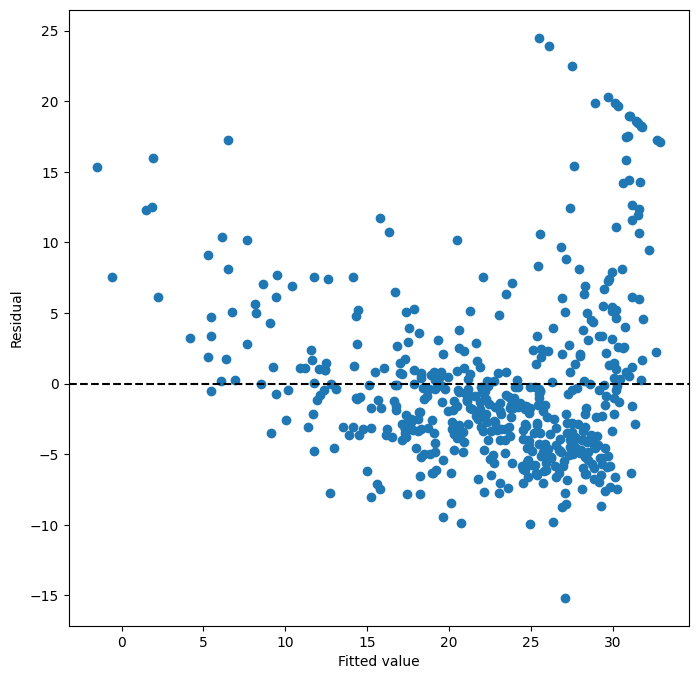

In [31]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');


## Multiple Linear Regression
Para ajustar un modelo de regresión lineal múltiple mediante mínimos cuadrados, nuevamente utilizamos el transformador `ModelSpec()` para construir la matriz del modelo y la variable de respuesta requeridas. Los argumentos de `ModelSpec()` pueden ser bastante generales, pero en este caso basta con una lista de nombres de columnas. Aquí consideramos un ajuste con las dos variables lstat y age.

In [49]:
# Ensure cell 307b7e22 with the import for MS is executed before this cell.
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     309.0
Date:                Mon, 04 Aug 2025   Prob (F-statistic):           2.98e-88
Time:                        20:35:03   Log-Likelihood:                -1637.5
No. Observations:                 506   AIC:                             3281.
Df Residuals:                     503   BIC:                             3294.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     33.2228      0.731     45.458      0.0

Observa cómo hemos compactado la primera línea en una expresión concisa que describe la construcción de 𝑋.

El conjunto de datos Boston contiene 12 variables, por lo que sería tedioso tener que escribir todas ellas para realizar una regresión con todos los predictores. En su lugar, podemos utilizar la siguiente forma abreviada: columns.drop().

In [34]:
terms = Boston.columns.drop('medv')
terms


Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

Ahora podemos ajustar el modelo con todas las variables utilizando el mismo constructor de la matriz del modelo.

In [48]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Mon, 04 Aug 2025   Prob (F-statistic):          2.23e-133
Time:                        20:34:00   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     41.6173      4.936      8.431      0.0

¿Qué pasa si queremos realizar una regresión utilizando todas las variables excepto una? Por ejemplo, en los resultados de la regresión anterior, la variable age tiene un valor $p$ alto. Por lo tanto, podríamos desear ejecutar una regresión excluyendo este predictor. La siguiente sintaxis da como resultado una regresión que utiliza todos los predictores excepto age.

In [47]:
minus_age = Boston.columns.drop(['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
results1 = model1.fit()
print(results1.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     124.1
Date:                Mon, 04 Aug 2025   Prob (F-statistic):          2.03e-134
Time:                        20:33:33   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3034.
Df Residuals:                     494   BIC:                             3085.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     41.5251      4.920      8.441      0.0

## Multivariate Goodness of Fit
Podemos acceder a los componentes individuales de results por nombre (usando dir(results) podemos ver qué está disponible). Por ejemplo, results.rsquared nos da el valor de $R^2$ y np.sqrt(results.scale) nos proporciona el error estándar residual (RSE).

Los factores de inflación de la varianza (VIF, por sus siglas en inglés) son a veces útiles para evaluar el efecto de la colinealidad en la matriz del modelo de una regresión. Calcularemos los VIF en nuestro ajuste de regresión múltiple y aprovecharemos para introducir la idea de list comprehension (comprensión de listas).

###Comprensión de listas
A menudo nos encontramos con una secuencia de objetos que queremos transformar para alguna otra tarea. A continuación, calculamos el VIF para cada característica en nuestra matriz
𝑋 y generamos un data frame cuyo índice coincide con las columnas de 𝑋.
La comprensión de listas puede simplificar este tipo de tareas.

Las comprensiones de listas son formas simples y potentes de crear listas de objetos en Python. El lenguaje también admite comprensiones de diccionarios y generadores, aunque estos están fuera del alcance de este texto.

Veamos un ejemplo: calculamos el VIF para cada una de las variables en la matriz del modelo 𝑋, utilizando la función variance_inflation_factor().


In [37]:
vals = [VIF(X, i)
        for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif':vals},
                   index=X.columns[1:])
vif


,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


La función `VIF()` toma dos argumentos: un dataframe o array, y el índice de la columna de la variable. En el código anterior, llamamos a `VIF()` sobre la marcha para todas las columnas en 𝑋.

Hemos excluido la columna 0 `(el intercepto)`, ya que no es de interés. En este caso, los valores de VIF no resultan particularmente interesantes.

El objeto vals anterior podría haberse construido con el siguiente bucle for:

In [39]:
vals = []
for i in range(1, X.values.shape[1]):
    vals.append(VIF(X.values, i))


La comprensión de listas nos permite realizar este tipo de operaciones repetitivas de una manera más sencilla y directa.

## Términos de interacción

Es fácil incluir términos de interacción en un modelo lineal utilizando 'ModelSpec()'. Incluir una tupla '("lstat", "age")' le indica al constructor de la matriz del modelo que debe incluir un término de interacción entre lstat y age.

In [46]:
X = MS(['lstat',
        'age',
        ('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
results2 = model2.fit()
print(results2.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     209.3
Date:                Mon, 04 Aug 2025   Prob (F-statistic):           4.86e-88
Time:                        20:32:42   Log-Likelihood:                -1635.0
No. Observations:                 506   AIC:                             3278.
Df Residuals:                     502   BIC:                             3295.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     36.0885      1.470     24.553      0.0

## Non-linear Transformations of the Predictors
El constructor de la matriz del modelo puede incluir términos más allá de simples nombres de columnas e interacciones. Por ejemplo, la función `poly()` provista en `ISLP` indica que se deben agregar a la matriz del modelo columnas que representen funciones polinómicas de su primer argumento.

In [45]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
print(results3.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     337.3
Date:                Mon, 04 Aug 2025   Prob (F-statistic):          7.03e-120
Time:                        20:30:58   Log-Likelihood:                -1561.0
No. Observations:                 506   AIC:                             3130.
Df Residuals:                     502   BIC:                             3147.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
intercept               

El valor $p$ prácticamente nulo asociado al término cuadrático (es decir, la tercera fila del resultado anterior) sugiere que este término mejora el modelo.

Además, por defecto, las columnas creadas por poly() no incluyen un término de intercepto, ya que este es añadido automáticamente por MS().

Utilizamos la función anova_lm() para cuantificar aún más en qué medida el ajuste cuadrático es superior al ajuste lineal.

In [44]:
anova_lm(results1, results3)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


Aquí, `results1` representa un modelo lineal que contiene los predictores `lstat` y `age`, mientras que `results3` corresponde al modelo ampliado anterior con un término cuadrático en `lstat`. La función `anova_lm()` realiza una prueba de hipótesis comparando ambos modelos.

La hipótesis nula es que el término cuadrático no es necesario, y la hipótesis alternativa es que lo es.
En este caso, el estadístico `F es 177.28` y el valor $p$ asociado es cero.

Esto constituye una evidencia muy clara de que el polinomio cuadrático en `lstat` mejora el modelo lineal. No es sorprendente, ya que anteriormente vimos señales de no linealidad en la relación entre `medv` y `lstat`.

La función `anova_lm()` puede aceptar más de dos modelos anidados como entrada, en cuyo caso compara cada par sucesivo de modelos.
Esto también explica por qué hay valores NaN en la primera fila, ya que no hay un modelo anterior con el cual comparar el primero.



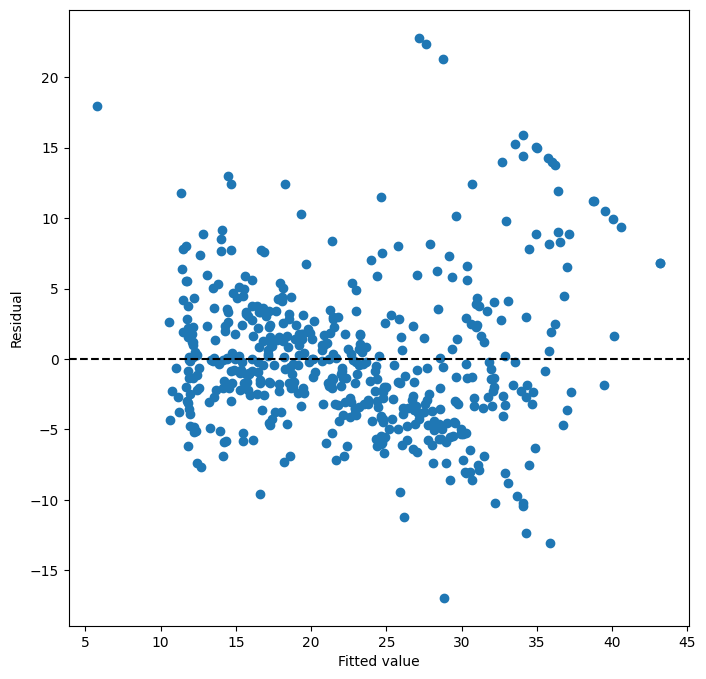

In [ ]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');


Vemos que cuando se incluye el término cuadrático en el modelo, hay poco patrón discernible en los residuos. Para crear un ajuste cúbico o de mayor grado, simplemente podemos cambiar el argumento degree en `poly()`.


## Qualitative Predictors
Aquí utilizamos el conjunto de datos Carseats, que está incluido en el paquete `ISLP`. Intentaremos predecir las ventas de asientos infantiles para automóvil (Sales) en 400 ubicaciones, basándonos en una serie de predictores.

In [ ]:
Carseats = load_data('Carseats')
Carseats.columns


Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

###Carseats
 El conjunto de datos `Carseats` incluye predictores cualitativos como `ShelveLoc`, un indicador de la calidad de la ubicación del estante, es decir, el espacio dentro de una tienda donde se exhibe el asiento para auto. El predictor `ShelveLoc` toma tres posibles valores: Bad, Medium y Good.

Dada una variable cualitativa como ShelveLoc, `ModelSpec()` genera automáticamente variables dummy. Estas variables se conocen comúnmente como una codificación one-hot `(one-hot encoding)` de la característica categórica. Sus columnas suman uno, por lo que, para evitar colinealidad con el intercepto, se elimina la primera columna.

En el ejemplo a continuación, vemos que la columna `ShelveLoc[Bad]` ha sido eliminada, ya que Bad es el primer nivel de ShelveLoc.

A continuación, ajustamos un modelo de regresión múltiple que incluye algunos términos de interacción.

In [ ]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'),
                   ('Price', 'Age')]
X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())


,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288


En la primera línea anterior, convertimos allvars en una lista para poder añadir los términos de interacción unas líneas más abajo. Nuestro constructor de la matriz del modelo ha creado una variable dummy `ShelveLoc[Good]` que toma el valor 1 si la ubicación del estante es buena, y 0 en caso contrario. También ha creado una variable dummy `ShelveLoc[Medium]` que vale 1 si la ubicación del estante es media, y 0 en caso contrario. Una ubicación de estante mala corresponde a un valor cero en ambas variables dummy.

El hecho de que el coeficiente de ShelveLoc`[Good]` en los resultados de la regresión sea positivo indica que una buena ubicación del estante se asocia con mayores ventas (en comparación con una ubicación mala). Asimismo, `ShelveLoc[Medium]` tiene un coeficiente positivo más pequeño, lo que indica que una ubicación media produce más ventas que una ubicación mala, pero menos que una buena.

